# Audio Fingerprinting Pipeline: Step-by-Step Explanation and Visualization

This notebook explains the steps involved in this audio fingerprinting pipeline including:
- loading audio
- computing spectrograms
- detecting peaks
- generating fingerprints
- storing them in a database
- matching for recognition.

Visualizations are provided for each step to aid understanding.    

## 1. Import Required Libraries

In [1]:
# Import libraries for audio processing, visualization, and database operations
import matplotlib.pyplot as plt
from pathlib import Path
from audio_processing.audio import load_audio, add_noise
from audio_processing.spectrogram import spectrogram, find_peaks
from controllers.database import connect, init_db
from controllers.fingerprint import generate_fingerprints
from controllers.song_manager import persist_song_data

## 2. Load Audio Files

Load WAV audio files from the specified directory using the `load_audio` function.

In [2]:
# Specify the folder containing WAV files
clean_folder = Path("data", "assets", "clean_wavs")

# Load the first audio file for demonstration
wav_paths = list(clean_folder.glob("*.wav"))
if not wav_paths:
    raise FileNotFoundError("No WAV files found in the specified directory.")

wav_path = wav_paths[0]
y, sr = load_audio(wav_path.as_posix())
print(f"Loaded {wav_path.name}, Sample Rate: {sr}, Audio Length: {len(y)/sr:.2f} seconds")

Loaded music-hd-0022.wav, Sample Rate: 22050, Audio Length: 166.45 seconds


## 3. Compute Spectrogram

Compute the spectrogram for the loaded audio file using the `spectrogram` function.

In [16]:
# Compute the spectrogram for the loaded audio
default_n_fft = 4096
default_hop_length = 512
S_db = spectrogram(y, n_fft=default_n_fft, hop_length=default_hop_length)
print(f"Spectrogram shape: {S_db.shape}")

Spectrogram shape: (2049, 7169)


## 4. Visualize Spectrogram

Display the computed spectrogram using matplotlib's `imshow` for a clear time-frequency representation.

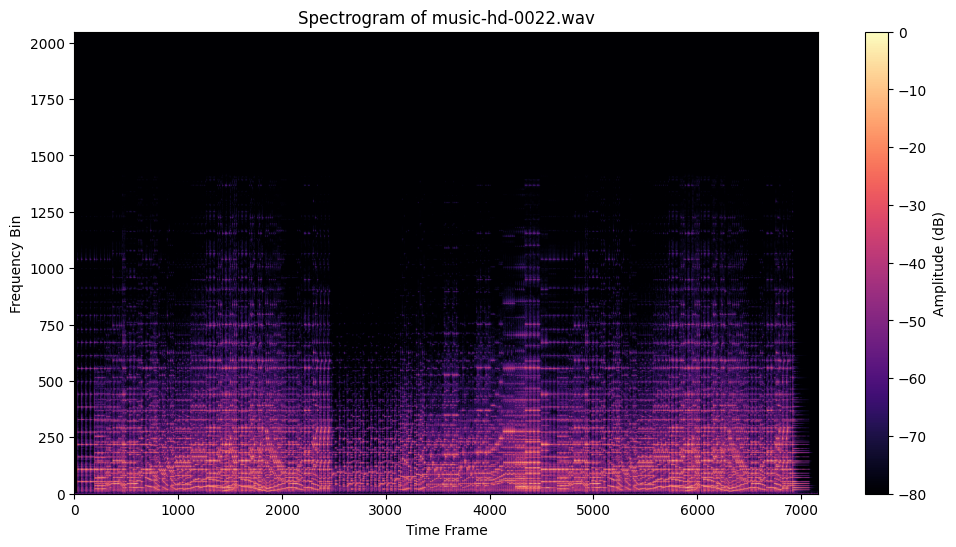

In [17]:
# Visualize the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram of {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

## 5. Find Spectrogram Peaks

Detect local maxima (peaks) in the spectrogram using the `find_peaks` function.

In [18]:
# Find peaks in the spectrogram
amp_min = -60  # Minimum amplitude threshold for peak detection
peaks = find_peaks(S_db, amp_min=amp_min)
print(f"Number of peaks detected: {len(peaks)}")

Number of peaks detected: 9246


## 6. Visualize Peaks on Spectrogram

Overlay the detected peaks on the spectrogram visualization using scatter plots for clarity.

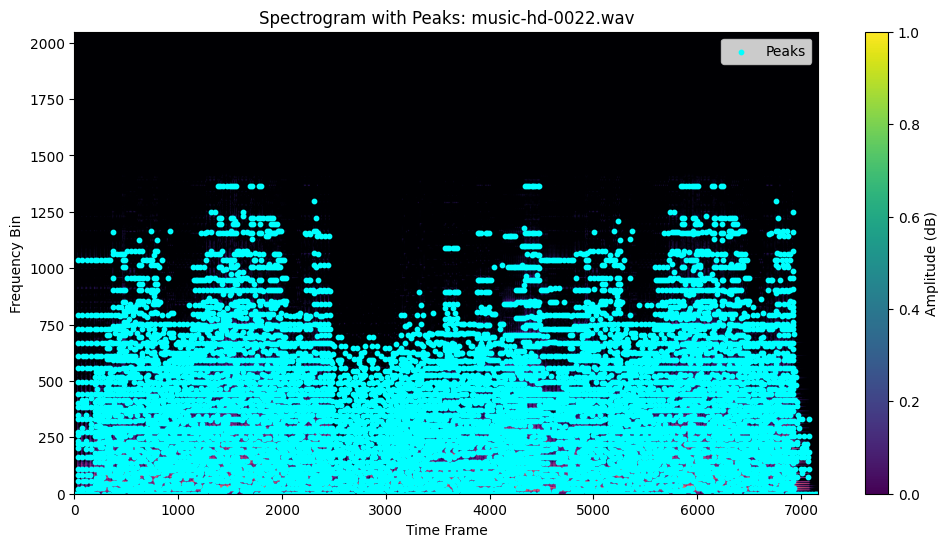

In [6]:
# Visualize peaks on the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db, aspect="auto", origin="lower", cmap="magma")
if peaks:
    times, freqs = zip(*peaks)
    plt.scatter(times, freqs, s=10, c="cyan", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram with Peaks: {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()

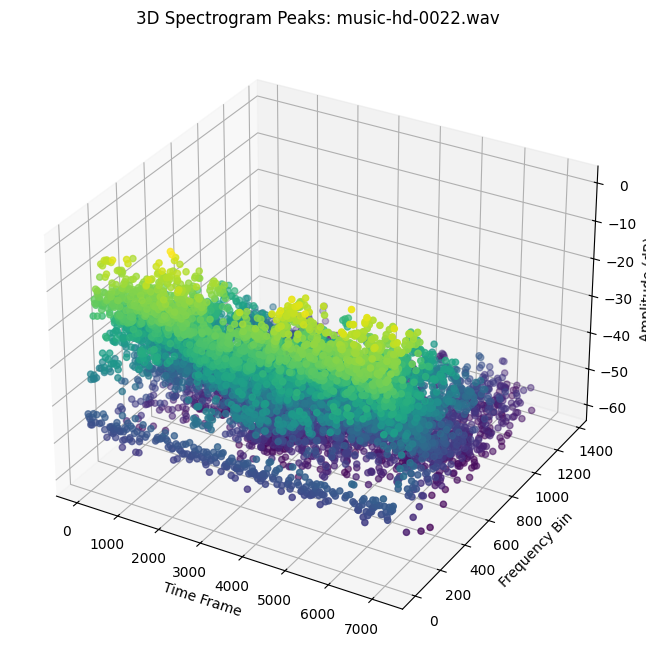

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
if peaks:
    times, freqs = zip(*peaks)
    amplitudes = S_db[freqs, times]
    ax.scatter(times, freqs, amplitudes, c=amplitudes, cmap='viridis', s=20)
ax.set_xlabel('Time Frame')
ax.set_ylabel('Frequency Bin')
ax.set_zlabel('Amplitude (dB)')
ax.set_title(f'3D Spectrogram Peaks: {wav_path.name}')
plt.show()

# Data augmentation

The search works and does match the correct audio file, but the number of matching fingerprints is very low - maybe 20-30 out of 3000+ fingerprints in the database. This is likely because the audio files in the database are clean, while the recording from my phone has a lot of noise and artifacts.
Since I'm not getting great results from the recording with my phone, I'm trying to add some noise to the original audio files. The idea is to get fingerprints from this noisy audio and associate them with the original audio files in the database.

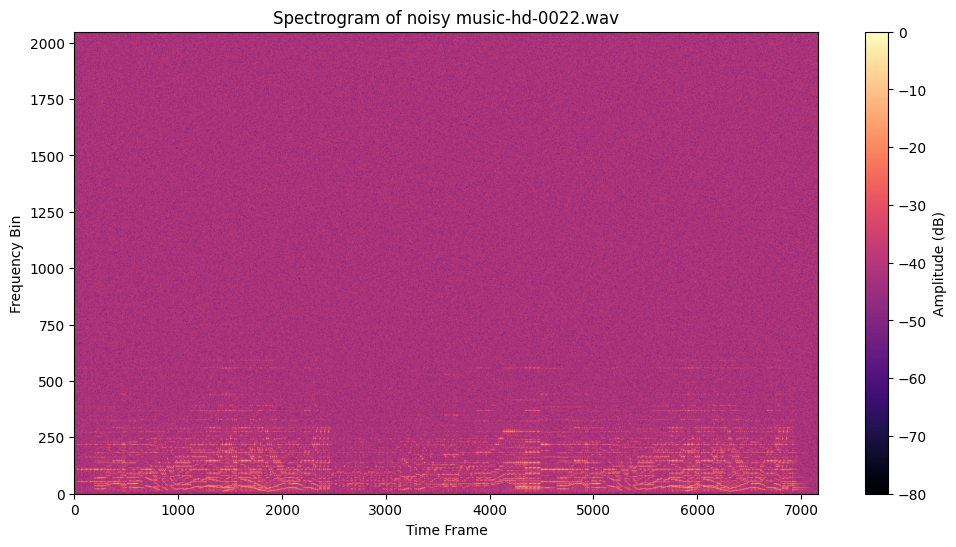

In [15]:
y_noisy = add_noise(y, noise_level=0.1)
S_db_noisy = spectrogram(y_noisy)

# Visualize the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db_noisy, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram of noisy {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()


## 7. Generate Fingerprints from Peaks

Generate fingerprints from the detected peaks using the `generate_fingerprints` function and display some examples.

In [9]:
# Generate fingerprints from peaks
fingerprints = generate_fingerprints(peaks)
print(f"Number of fingerprints generated: {len(fingerprints)}")
# Display a few example fingerprints
print("Example fingerprints:", fingerprints[:5])

Number of fingerprints generated: 22732
Example fingerprints: [('ba598f1265790ce7911e', np.int64(9)), ('e56a3d1a60331f1a54f6', np.int64(9)), ('61e9bbc641f0ff26a404', np.int64(9)), ('f498373f6ab3082a623e', np.int64(9)), ('06b199f73163467c729d', np.int64(9))]


## 8. Persist Song Data to Database

Store the generated fingerprints in the database using the `persist_song_data` function.

In [10]:
# Store fingerprints in the database
conn = connect()
init_db(conn)
song_name = wav_path.stem
persist_song_data(conn, song_name, fingerprints)
print(f"Persisted {len(fingerprints)} fingerprints for song '{song_name}' in the database.")

Persisted 22732 fingerprints for song 'music-hd-0022' in the database.


## 9. Match Fingerprints and Display Results

Match fingerprints against the database using the `match` function and display recognition results.

In [32]:
# Optional overide fingerprints with those from mic recording

import time
from audio_processing.audio import record_audio

for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")
print(f"Shape of input: {y_mic.shape}")
S_db_mic = spectrogram(y_mic)

peaks_mic = find_peaks(S_db_mic)
fps_mic = generate_fingerprints(peaks_mic)
print(f"Mic clip: {len(peaks_mic)} peaks, {len(fps_mic)} fingerprints")
fingerprints = fps_mic


--- Recording starts in 3 seconds ---
--- Recording starts in 2 seconds ---
--- Recording starts in 1 seconds ---
Recording now...
Recording done.
Shape of input: (154350,)
Mic clip: 351 peaks, 2307 fingerprints


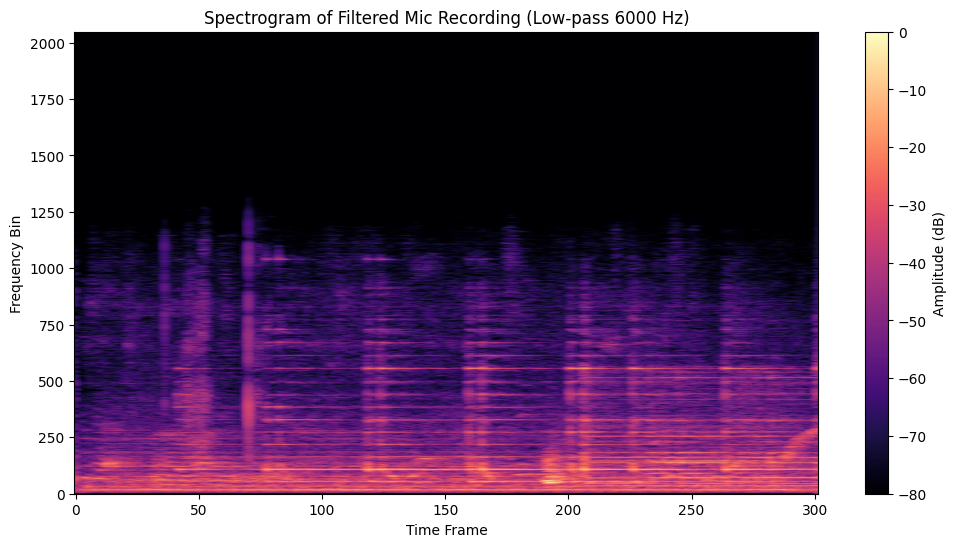

Filtered Mic: 465 peaks, 3031 fingerprints


In [55]:
# Apply a low-pass filter to reduce high-frequency noise in mic input
from scipy.signal import butter, filtfilt

def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Filter the mic audio: low-pass at 6000 Hz (adjust cutoff as needed)
cutoff_freq = 6000  # Hz
y_mic_filtered = lowpass_filter(y_mic, cutoff_freq, sr_mic)

# Recompute spectrogram with filtered audio
S_db_mic_filtered = spectrogram(y_mic_filtered)

# Visualize filtered spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_filtered, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram of Filtered Mic Recording (Low-pass {cutoff_freq} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

# Update peaks and fingerprints with filtered mic
peaks_mic_filtered = find_peaks(S_db_mic_filtered, amp_min=amp_min)
fps_mic_filtered = generate_fingerprints(peaks_mic_filtered)
print(f"Filtered Mic: {len(peaks_mic_filtered)} peaks, {len(fps_mic_filtered)} fingerprints")

# Use filtered fingerprints for matching
fingerprints = fps_mic_filtered

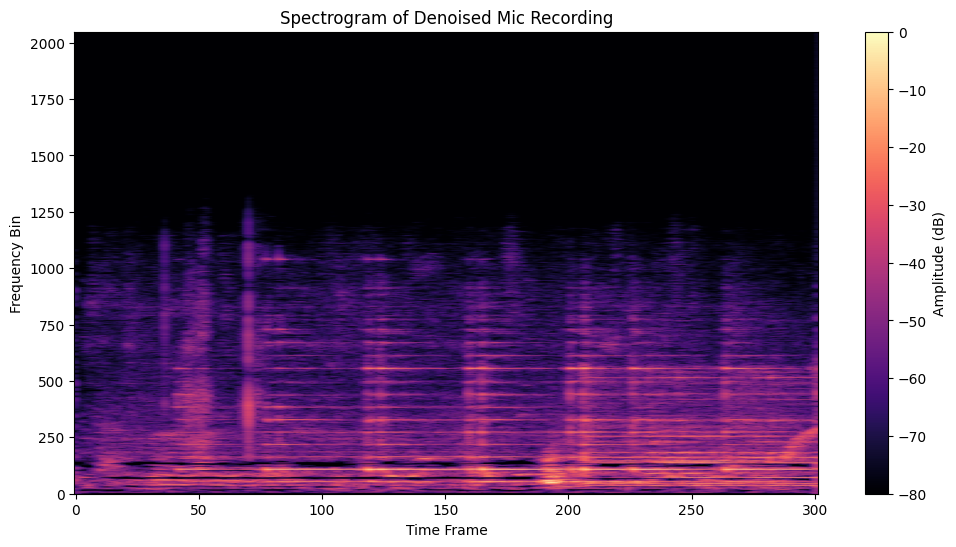

Denoised Mic: 468 peaks, 3062 fingerprints


In [56]:
# Apply noise reduction to remove background noise from mic audio
import librosa

# Estimate noise profile from the first 0.5 seconds (assuming it's relatively silent or noisy)
noise_length = int(0.5 * sr_mic)  # 0.5 seconds
if len(y_mic_filtered) > noise_length:
    noise_clip = y_mic_filtered[:noise_length]
else:
    noise_clip = y_mic_filtered

# Reduce noise using spectral subtraction
y_mic_denoised = librosa.effects.remix(y_mic_filtered, intervals=librosa.effects.split(y_mic_filtered, top_db=20))  # Simple voice activity detection, but for noise reduction:
# Better: use librosa's decompose module or manual spectral subtraction

# For spectral subtraction, compute noise spectrum
noise_stft = librosa.stft(noise_clip, n_fft=default_n_fft, hop_length=default_hop_length)
noise_power = np.mean(np.abs(noise_stft)**2, axis=1)

# Compute STFT of filtered mic
mic_stft = librosa.stft(y_mic_filtered, n_fft=default_n_fft, hop_length=default_hop_length)

# Spectral subtraction
mic_stft_denoised = mic_stft - noise_power[:, np.newaxis] * 0.5  # Subtract scaled noise
mic_stft_denoised = np.maximum(mic_stft_denoised, 0)  # Ensure non-negative

# Inverse STFT
y_mic_denoised = librosa.istft(mic_stft_denoised, hop_length=default_hop_length)

# Recompute spectrogram with denoised audio
S_db_mic_denoised = spectrogram(y_mic_denoised)

# Visualize denoised spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_denoised, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title("Spectrogram of Denoised Mic Recording")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

# Update peaks and fingerprints with denoised mic
peaks_mic_denoised = find_peaks(S_db_mic_denoised, amp_min=amp_min)
fps_mic_denoised = generate_fingerprints(peaks_mic_denoised)
print(f"Denoised Mic: {len(peaks_mic_denoised)} peaks, {len(fps_mic_denoised)} fingerprints")

# Use denoised fingerprints for matching
fingerprints = fps_mic_denoised

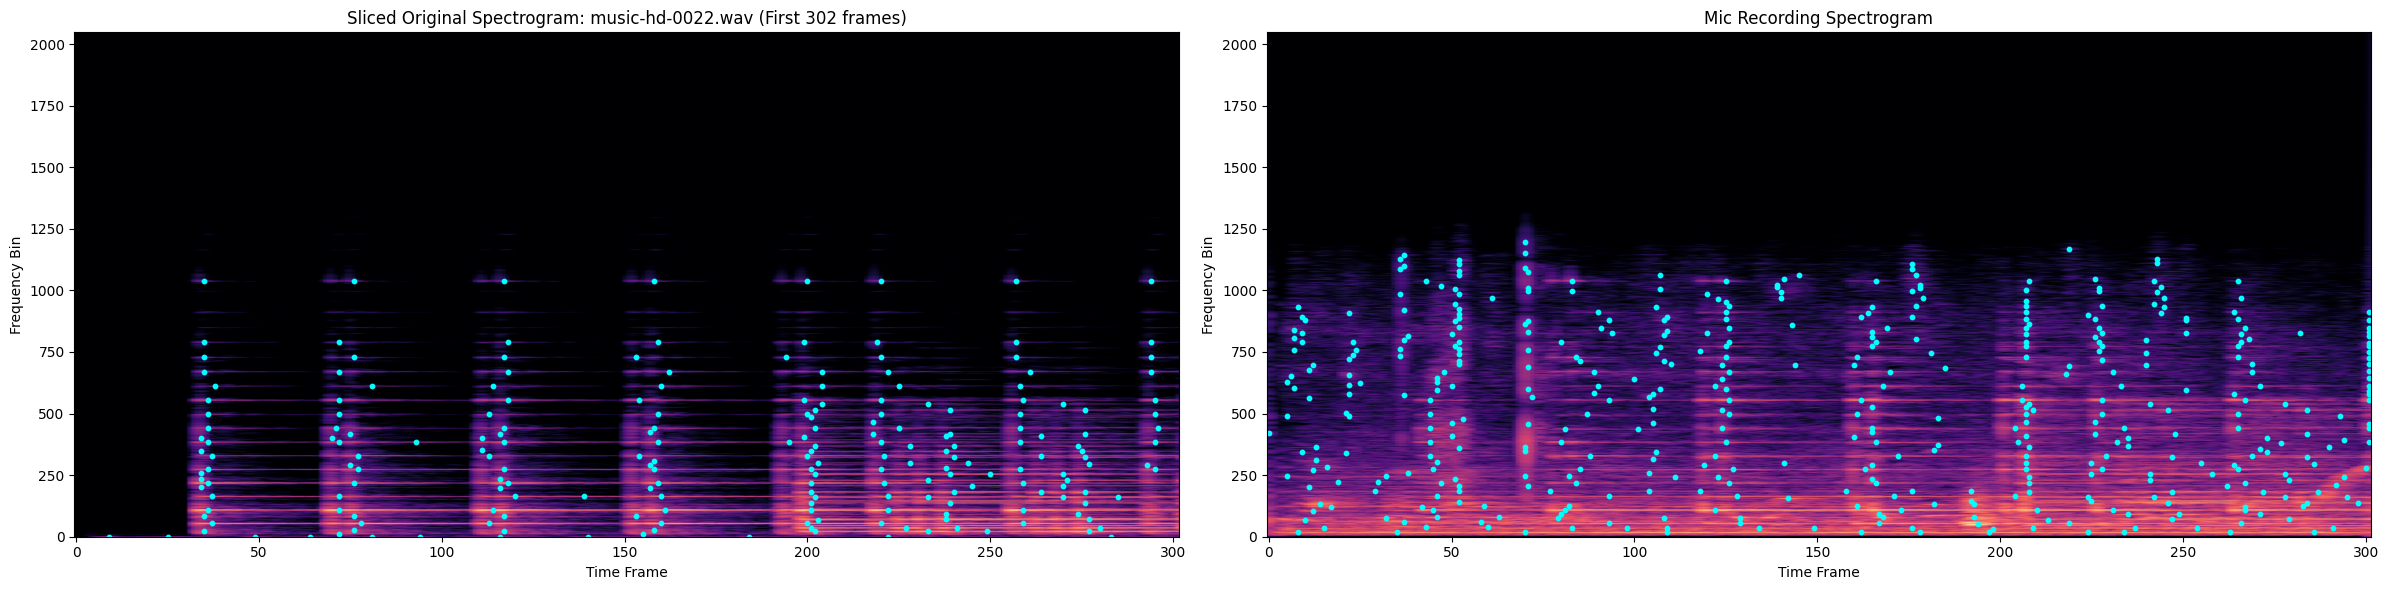

Sliced original shape: (2049, 302), Mic shape: (2049, 302)
Sliced original max dB: -5.42, Mic max dB: 0.00
Sliced original min dB: -80.00, Mic min dB: -80.00


In [57]:
import numpy as np


# Assume mic recording is from the beginning of the song; slice original to match mic's time frames
mic_time_frames = S_db_mic.shape[1]
S_db_original_slice = S_db[:, :mic_time_frames]

S_db_mic = S_db_mic_filtered

# Compare sliced original vs. mic spectrograms side-by-side
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

# Sliced original spectrogram
axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Sliced Original Spectrogram: {wav_path.name} (First {mic_time_frames} frames)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")
peaks_original_filtered = [(t, f) for t, f in peaks if t < mic_time_frames]
if peaks_original_filtered:
    times, freqs = zip(*peaks_original_filtered)
    axes[0].scatter(times, freqs, s=10, c="cyan", label="Peaks")

# Mic spectrogram
axes[1].imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Mic Recording Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")
peaks_mic_filtered = [(t, f) for t, f in peaks_mic_filtered if t < mic_time_frames]
if peaks_mic_filtered:
    times, freqs = zip(*peaks_mic_filtered)
    axes[1].scatter(times, freqs, s=10, c="cyan", label="Peaks")

plt.tight_layout()
plt.show()

# Optional: Print key differences
print(f"Sliced original shape: {S_db_original_slice.shape}, Mic shape: {S_db_mic.shape}")
print(f"Sliced original max dB: {np.max(S_db_original_slice):.2f}, Mic max dB: {np.max(S_db_mic):.2f}")
print(f"Sliced original min dB: {np.min(S_db_original_slice):.2f}, Mic min dB: {np.min(S_db_mic):.2f}")

After normalization - Original max dB: 0.00, Mic max dB: 0.00


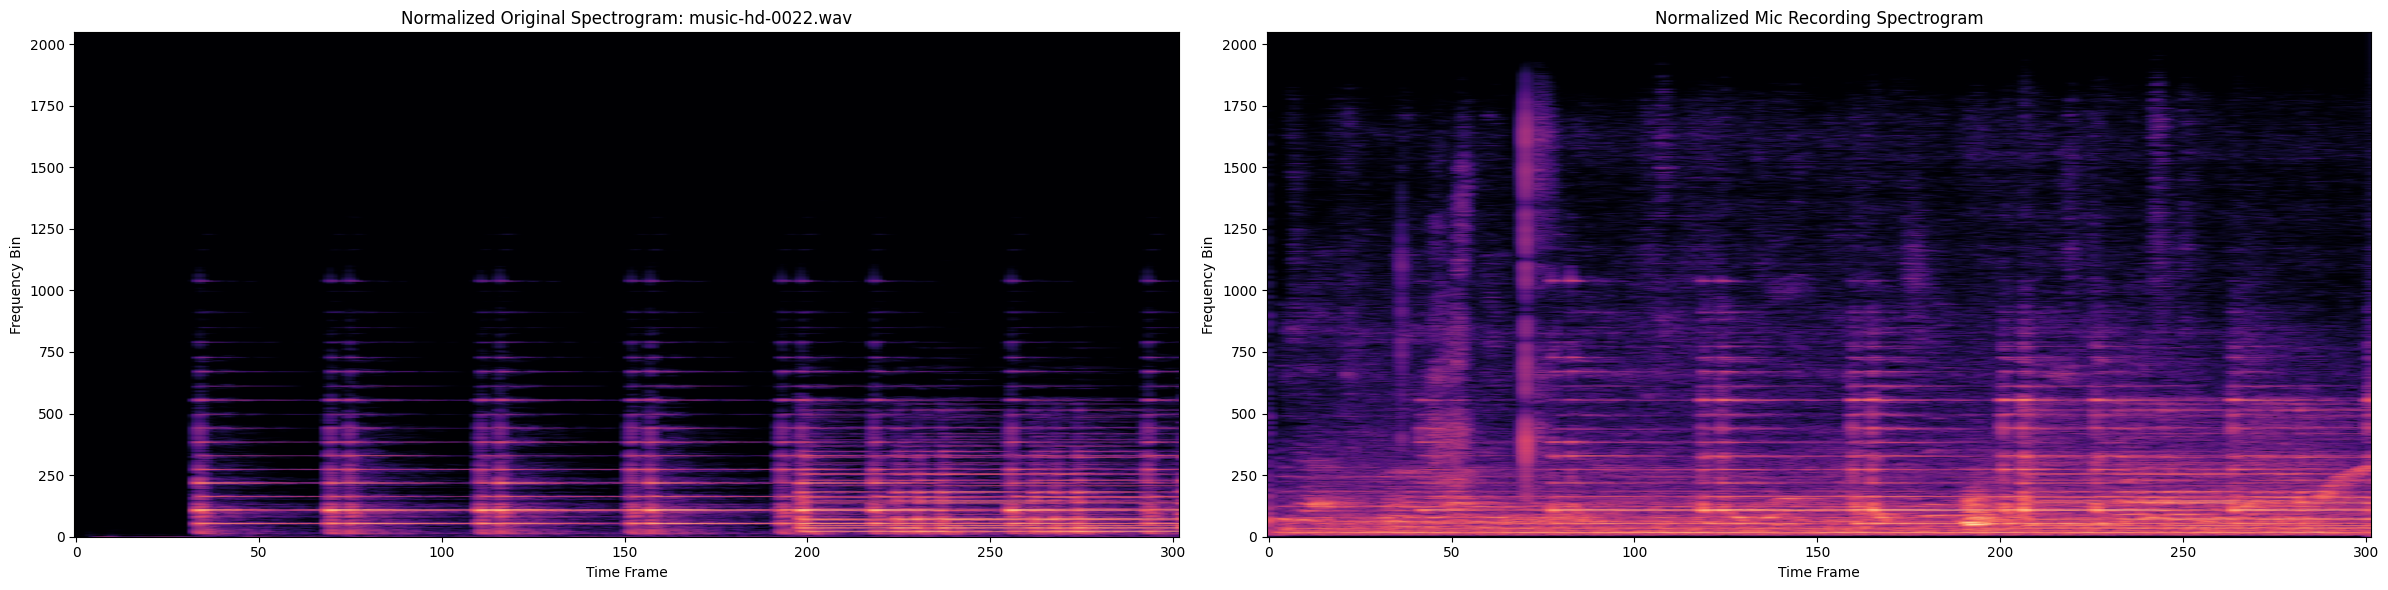

Normalized Original: 256 peaks, 1762 fingerprints
Normalized Mic: 618 peaks, 4105 fingerprints
Matching fingerprints between normalized original and mic: 0


In [34]:
# Normalize amplitudes: Scale both spectrograms so max dB is 0 for fair comparison
S_db_original_norm = S_db_original_slice - np.max(S_db_original_slice)
S_db_mic_norm = S_db_mic - np.max(S_db_mic)

print(f"After normalization - Original max dB: {np.max(S_db_original_norm):.2f}, Mic max dB: {np.max(S_db_mic_norm):.2f}")

# Visualize normalized spectrograms side-by-side
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

axes[0].imshow(S_db_original_norm, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Normalized Original Spectrogram: {wav_path.name}")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_mic_norm, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Normalized Mic Recording Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Recompute peaks and fingerprints with normalized spectrograms
peaks_original_norm = find_peaks(S_db_original_norm, amp_min=amp_min)
peaks_mic_norm = find_peaks(S_db_mic_norm, amp_min=amp_min)

fps_original_norm = generate_fingerprints(peaks_original_norm)
fps_mic_norm = generate_fingerprints(peaks_mic_norm)

print(f"Normalized Original: {len(peaks_original_norm)} peaks, {len(fps_original_norm)} fingerprints")
print(f"Normalized Mic: {len(peaks_mic_norm)} peaks, {len(fps_mic_norm)} fingerprints")

# Compare fingerprints: Check how many match between normalized versions
matches_norm = set((h, offset) for h, offset in fps_original_norm) & set((h, offset) for h, offset in fps_mic_norm)
print(f"Matching fingerprints between normalized original and mic: {len(matches_norm)}")

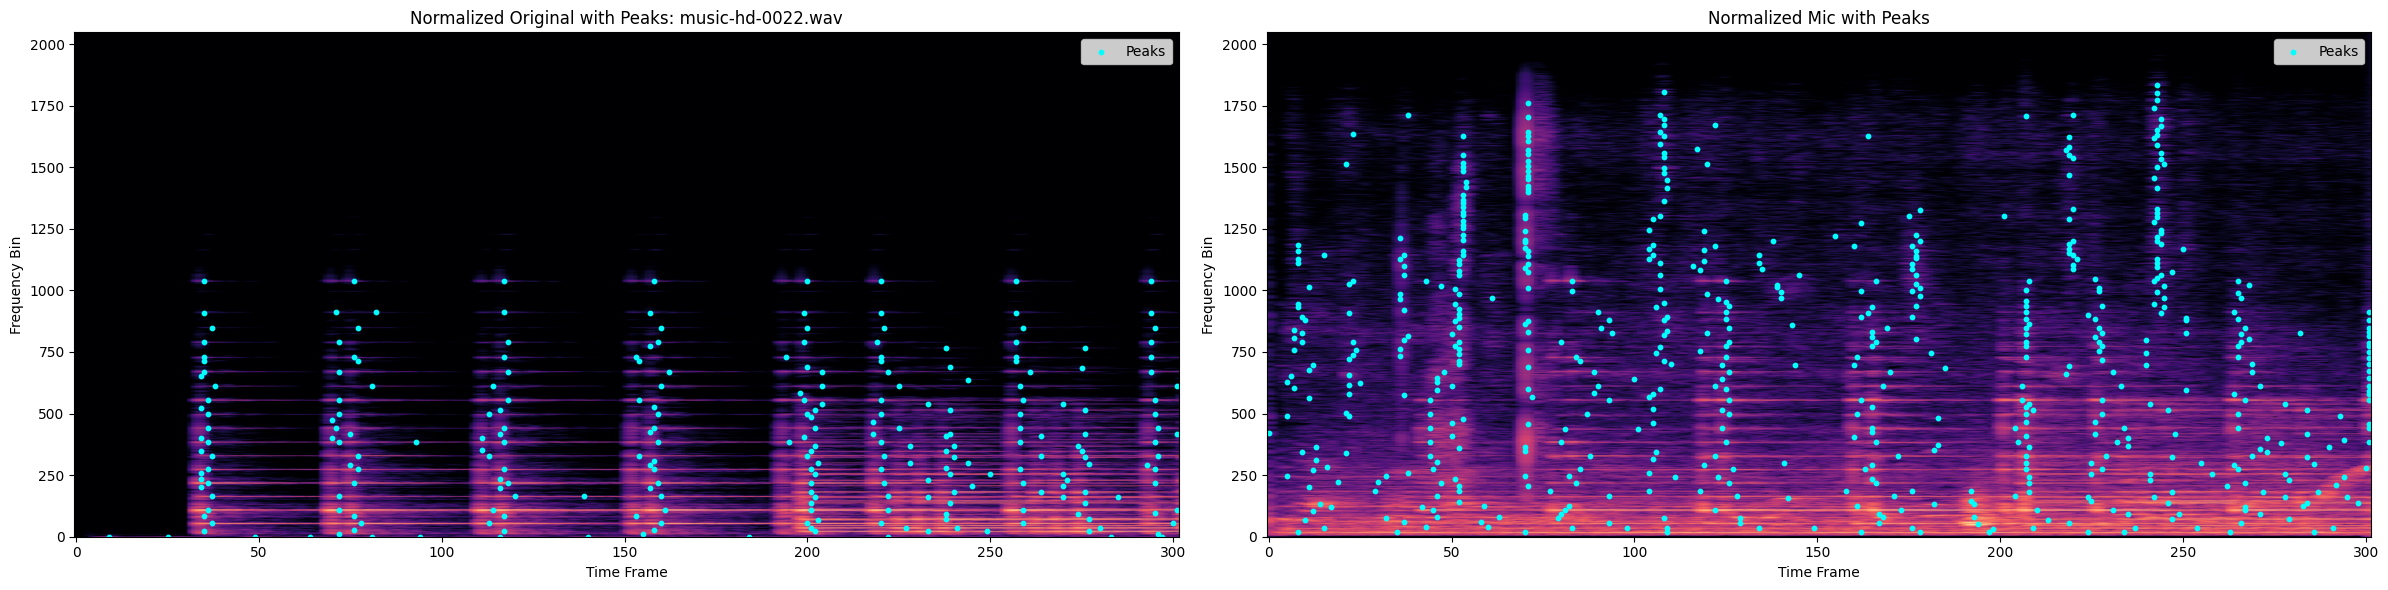

In [35]:

# Visualize peaks on normalized spectrograms
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

# Normalized original with peaks
axes[0].imshow(S_db_original_norm, aspect="auto", origin="lower", cmap="magma")
if peaks_original_norm:
    times, freqs = zip(*peaks_original_norm)
    axes[0].scatter(times, freqs, s=10, c="cyan", label="Peaks")
axes[0].set_title(f"Normalized Original with Peaks: {wav_path.name}")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")
axes[0].legend()

# Normalized mic with peaks
axes[1].imshow(S_db_mic_norm, aspect="auto", origin="lower", cmap="magma")
if peaks_mic_norm:
    times, freqs = zip(*peaks_mic_norm)
    axes[1].scatter(times, freqs, s=10, c="cyan", label="Peaks")
axes[1].set_title("Normalized Mic with Peaks")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")
axes[1].legend()

plt.tight_layout()
plt.show()

Best shift: 19 frames, Max common peaks: 61


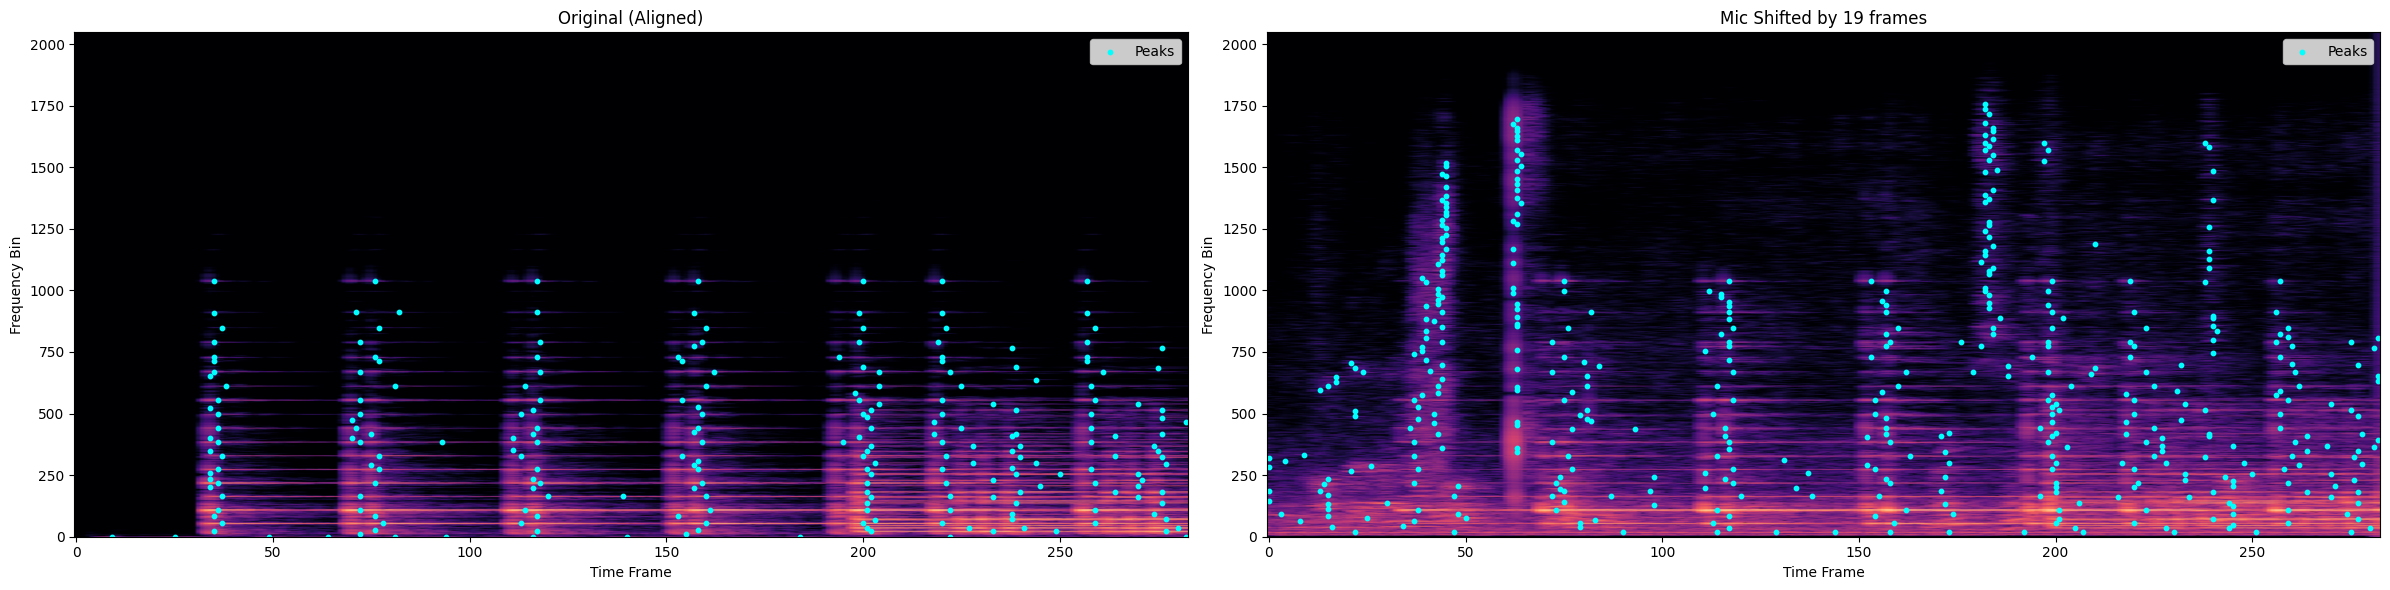

Matching fingerprints after alignment: 80


In [23]:
# Since the audios may not be aligned, find the best time shift for maximum peak overlap
import numpy as np

max_shift = 50  # Max frames to shift (adjust as needed)
best_shift = 0
max_common = 0
shift_counts = []

for shift in range(-max_shift, max_shift + 1):
    if shift < 0:
        # Shift mic left (earlier)
        mic_shifted = S_db_mic_norm[:, -shift:]  # Take later part
        orig_compare = S_db_original_norm[:, :mic_shifted.shape[1]]
    elif shift > 0:
        # Shift mic right (later)
        mic_shifted = S_db_mic_norm[:, shift:]
        orig_compare = S_db_original_norm[:, :mic_shifted.shape[1]]
    else:
        mic_shifted = S_db_mic_norm
        orig_compare = S_db_original_norm

    # Recompute peaks for shifted
    peaks_mic_shifted = find_peaks(mic_shifted, amp_min=amp_min)
    peaks_orig_compare = find_peaks(orig_compare, amp_min=amp_min)

    # Adjust mic peaks for shift
    peaks_mic_adjusted = [(t + abs(shift) if shift < 0 else t, f) for t, f in peaks_mic_shifted]

    common = len(set(peaks_orig_compare) & set(peaks_mic_adjusted))
    shift_counts.append((shift, common))
    if common > max_common:
        max_common = common
        best_shift = shift

print(f"Best shift: {best_shift} frames, Max common peaks: {max_common}")

# Apply best shift and visualize
shift = best_shift
if shift < 0:
    mic_shifted = S_db_mic_norm[:, -shift:]
    orig_compare = S_db_original_norm[:, :mic_shifted.shape[1]]
    peaks_mic_shifted = find_peaks(mic_shifted, amp_min=amp_min)
    peaks_mic_adjusted = [(t - shift, f) for t, f in peaks_mic_shifted]  # Adjust back
else:
    mic_shifted = S_db_mic_norm[:, shift:]
    orig_compare = S_db_original_norm[:, :mic_shifted.shape[1]]
    peaks_mic_shifted = find_peaks(mic_shifted, amp_min=amp_min)
    peaks_mic_adjusted = peaks_mic_shifted

peaks_orig_compare = find_peaks(orig_compare, amp_min=amp_min)

# Visualize aligned
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
axes[0].imshow(orig_compare, aspect="auto", origin="lower", cmap="magma")
if peaks_orig_compare:
    times, freqs = zip(*peaks_orig_compare)
    axes[0].scatter(times, freqs, s=10, c="cyan", label="Peaks")
axes[0].set_title(f"Original (Aligned)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")
axes[0].legend()

axes[1].imshow(mic_shifted, aspect="auto", origin="lower", cmap="magma")
if peaks_mic_shifted:
    times, freqs = zip(*peaks_mic_shifted)
    axes[1].scatter(times, freqs, s=10, c="cyan", label="Peaks")
axes[1].set_title(f"Mic Shifted by {shift} frames")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")
axes[1].legend()

plt.tight_layout()
plt.show()

# Recompute fingerprints for aligned versions
fps_orig_aligned = generate_fingerprints(peaks_orig_compare)
fps_mic_aligned = generate_fingerprints(peaks_mic_shifted)
matches_aligned = set((h, offset) for h, offset in fps_orig_aligned) & set((h, offset) for h, offset in fps_mic_aligned)
print(f"Matching fingerprints after alignment: {len(matches_aligned)}")

In [13]:
# Match fingerprints against the database and display results
import controllers.match_service

match_service = controllers.match_service.MatchService()
match_service.conn = conn
result = match_service.match_fingerprints(fingerprints)
if result:
    top_song, top_score = result
    print(f"Recognition results, top match is: {top_song} (score: {top_score})")
else:
    print("No match found.")

Recognizing audio from 843 fingerprints...

Total songs in DB: 23

Best match: music-hd-0022 with score 8

No match found.


In [14]:
offset_histograms = {}


matches = []
cur = conn.cursor()
for h, offset in fingerprints:
    cur.execute("SELECT offset FROM fingerprints WHERE hash=? AND song_id=(SELECT id FROM songs WHERE name=?)", (h, top_song))
    for (db_offset,) in cur.fetchall():
        matches.append(db_offset - offset)
offset_histograms[top_song] = matches


# Convert offsets from frames to seconds
hop_length = default_hop_length  # use the same hop_length as in spectrogram
offset_histograms_seconds = {}
for song_id, offsets in offset_histograms.items():
    offsets_sec = [offset * hop_length / sr for offset in offsets]
    offset_histograms_seconds[song_id] = offsets_sec


plt.figure(figsize=(12, 6))
for song_id, offsets_sec in offset_histograms_seconds.items():
    if offsets_sec:
        plt.hist(offsets_sec, bins=100, alpha=0.5, label=song_id)


plt.title("Relative Time Offset Histograms (Mic vs Songs)")
plt.xlabel("Time offset (seconds)")
plt.ylabel("Count of matching fingerprints")
plt.legend()
#print min offset difference
print("Min offset difference (seconds):", min(abs(offset) for offsets in offset_histograms_seconds.values() for offset in offsets))

plt.show()

NameError: name 'top_song' is not defined

# Resources:

- [How Shazam Works (Probably!) - Computerphile](https://www.youtube.com/watch?v=RRsq9apr5QY)

- [But what is the Fourier Transform? A visual introduction.](https://www.youtube.com/watch?v=spUNpyF58BY)

- [Discrete Fourier Transform - Simple Step by Step
](https://www.youtube.com/watch?v=mkGsMWi_j4Q)

